#Analisis Faktor-Faktor yang Mempengaruhi Efesiensi Energi Kendaraan Listrik

##Nama : Akhmad Rafliansyah
##NIM : 2509116045
##Kelas : B

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/EV Energy Efficiency Dataset.csv'

In [ ]:
df = pd.read_csv(path)
df

,Model year,Make,Model,Vehicle class,Motor (kW),Recharge time (h),Energy Efficiency (km/kWh)
0,2012,Mitsubishi,i-MiEV,Subcompact,49,7.0,5.347594
1,2012,Nissan,LEAF,Mid-size,80,7.0,4.739336
2,2013,Ford,Focus Electric,Compact,107,4.0,5.000000
3,2013,Mitsubishi,i-MiEV,Subcompact,49,7.0,5.347594
4,2013,Nissan,LEAF,Mid-size,80,7.0,4.739336
...,...,...,...,...,...,...,...
1192,2026,Volvo,EX30 Twin Performance,Sport utility vehicle: Small,315,8.0,5.181347
1193,2026,Volvo,"EX30 Cross Country (18"" Wheels)",Sport utility vehicle: Small,315,8.0,4.255319
1194,2026,Volvo,"EX30 Cross Country (19"" Wheels)",Sport utility vehicle: Small,315,8.0,4.716981
1195,2026,Volvo,EX40,Sport utility vehicle: Small,185,8.0,5.076142


## Business Understanding

### Business objective
Business objective dari analisis ini adalah untuk Mengidentifikasi faktor apa saja yang mempengaruhi efisiensi dari energi kendaraan listrik agar dapat dikembangkan dan dievaluasi kedepannya, menganalisis hubungan antara spesifikasi kendaraan listrik terhadap dengan tingkat efesiensi energinya, serta mengkaji bagaimana tren perkembangan efesiensi energi kendaraan listrik dari tahun 2012-2026 guna memperoleh insight yang dapat digunakan sebagai dasar pengambilan keputusan dan pengembangan teknologi yang lebih efisien.

### Assess Situation
Dataset yang digunakan dalam analisis ini adalah kumpulan data spesifikasi komprehensif untuk 1.197 kendaraan listrik dari tahun 2012 hingga 2026. dataset ini berisi 7 kolom atau variabel utama. 3 kolom merupakan fitur kategorikal yaitu merek, model, dan kelas kendaraan. lalu 4 kolom lainnya yaitu fitur numerik yaitu tahun model, daya motor, waktu pengisian, dan efisiensi energi. Selain itu data juga menunjukan efesiensi energi yang berkisar sebesar 2,11 hingga 6,94 km/kwh dan satu merek mobil yang paling mendominasi efisiensi energinya yaitu tesla yang berkisar sebesar 28,2% dari total data. Tantangan yang mungkin akan muncul adalah ketidakseimbangan data antara merek mobil dan kelas kendaraannya, serta kemungkinan adanya outlier pada variabel daya kendaraan dan waktu pengisian daya. oleh karena itu, sebelum menganalisis dan memvisualisasi data, data harus di proses di bagian data preparation.

### Analytic goals
1. Mengidentifikasi variabel yang berpotensi mempengaruhi efisensi energi kendaraan listrik melalui analisis deskriptif.
2. Melakukan analisis korelasi antara spesifikasi teknis seperti tenaga kendaraan dan waktu pengisian dayanya dengan tingkat efisensi energi kendaraan listrik.
3. Membuat visualisasi data seperti line chart, bar chart atau scatter plot dari tren perkembangan efisiensi energi kendaraan listrik  dari tahun 2012-2026.

### Project plan
1. Mengumpulkan dan memahami dataset kendaraan litrik yang diperoleh dari kaggle.
2. Melakukan cleaning data atau pembersihan data seperti mencari missing value dan duplikasi.
3. Memilih variabel data yang relevan dengan tingkat efisiensi energi kendaraan listrik.
4. Melakukan analisis deskriptif untuk memahami kondisi dan karakteristrik datanya serta analisis korelasi untuk mengetahui hubungan antar variabel numerik.
5. Membuat Visualisasi data seperti line chart, bar chart, dan scatter plot untuk menampilkan tren perkembangan efisiensi energi kendaraan listrik dari tahun 2012-2026 serta melihat pola hubungan antar variabelnya.
6. Menjelaskan hasil analisis yang telah didapat, menyusun dan menarik kesimpulan, kamudian memberikan insight berdasarkan analisis yang telah dilakukan guna sebagai pendukung dalam pengambilan keputusan terhadap pengembangan energi kendaraan listrik yang efisien.  

#Struktur Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Model year                  1197 non-null   int64  
 1   Make                        1197 non-null   object 
 2   Model                       1197 non-null   object 
 3   Vehicle class               1197 non-null   object 
 4   Motor (kW)                  1197 non-null   int64  
 5   Recharge time (h)           1197 non-null   float64
 6   Energy Efficiency (km/kWh)  1197 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 65.6+ KB


1. Model Year: jumlah baris: 1197 Tipe Data: int64 Deskripsi: Tahun Model
2. Make: jumlah baris: 1197 Tipe Data: object Deskripsi: Merek
3. Model: jumlah baris: 1197 Tipe Data: object Deskripsi: Model
4. Vehicle class: jumlah baris: 1197 Tipe Data: object Deskripsi: Kelas Kendaraan
5. Motor (KW): jumlah baris: 1197 Tipe Data: int64 Deskripsi: daya motor listrik mobil
6. Recharge time (h): jumlah baris: 1197 Tipe Data: float64 Deskripsi: Waktu Pengisian
7. Energy Efficiency (km/kwh): jumlah baris: 1197 Tipe Data: float64 Deskripsi: efiensi energi

#Statistik Deskriptif

In [ ]:
df.describe(include='all')

,Model year,Make,Model,Vehicle class,Motor (kW),Recharge time (h),Energy Efficiency (km/kWh)
count,1197.000000,1197,1197,1197,1197.000000,1197.000000,1197.000000
unique,NaN,37,590,12,NaN,NaN,NaN
top,NaN,Tesla,Niro EV,Sport utility vehicle: Standard,NaN,NaN,NaN
freq,NaN,176,8,311,NaN,NaN,NaN
mean,2023.231412,NaN,NaN,NaN,341.289891,10.547285,4.453765
std,2.881857,NaN,NaN,NaN,152.722951,2.706302,0.856691
min,2012.000000,NaN,NaN,NaN,35.000000,3.000000,2.114165
25%,2022.000000,NaN,NaN,NaN,230.000000,8.500000,3.787879
50%,2024.000000,NaN,NaN,NaN,335.000000,10.500000,4.366812
75%,2025.000000,NaN,NaN,NaN,420.000000,12.000000,5.102041


1. Count (Kelengkapan Data)
Berdasarkan data, total baris data adalah 1197. Disemua kolom, semua datanya adalah 1197. Artinya semua kolom data memiliki data yang lengkap yaitu 1197 data.



---



2. Mean vs Median (Distribusi Data)

* Kolom Motor (kW)
  * Mean = 341.28
  * Median = 335

  Nilai mean sangat dekat dengan nilai median yang artinya distribusi daya kendaraan relatif simetris. Juga, Tidak ada outlier ekstrem yang mendominasi.

* Kolom Recharge time (h)
  * Mean = 10.54
  * Median = 10.50
 Nilai mean dan median hampir sama yang artinya waktu pengisian daya cederung normal dan stabil tanpa penyimpangan yang esktrem.

* Kolom Eneregy Efficiency (km/kWh)
  * Mean = 4.45
  * Median = 4.36 -
  Nilai mean sedikit lebih besar dari median yang artinya terdapat beberapa kendaraan dengan efisiensi energi tinggi yang membuat nilai rata rata naik

Kesimpulan: secara umum variabel numerik memberikan distribusi yang cukup seimbang. namun ada satu variabel yang sedikit skewness yaitu Energy Efficiency


---



3. Min dan Max (Validasi Logika)

* Motor (kW)
  * Min = 35
  * Max = 930

* Recharge time (h)
  * Min = 3
  * Max = 18.6

* Energy Efficiency (km/kWh)
  * Min = 2.11
  * Max = 6.94

Kesimpulan:
* Nilai Motor (kW) rentangnya lebar tapi tetap logis. Artinya mencerminkan variasi kendaraan dari EV kecil hingga performa tinggi.

* Nilai Recharge time (h) rentangnya masih masuk akal. Artinya terdepat perbedaan teknologi charging dan kapasitas baterai.

* Nilai Energy Efficiency (km/kWh) variasinya wajar menunjukkan adanya perbedaan efisiensi energi antar model kendaraan.



---



4. Standar Deviasi (std) - Variabilitas Data

* Motor (kW)
  * Mean = 341.28
  * Std = 152.72

* Recharge time (h)
  * Mean = 10.54
  * Std = 2.70

* Energy Efficiency (km/kWh)
  * Mean = 4.45
  * Std = 0.85

Kesimpulan:

* Pada kolom Motor (kW) Std tergolong sangat besar dar
* Pada kolom Profit, nilai standar deviasi yang jauh lebih besar (676,75) daripada rata-ratanya (417,48) mengindikasikan bahwa tingkat keuntungan antar transaksi sangat tidak stabil/bervariasi, mulai dari kerugian besar hingga keuntungan yang sangat tinggi.


#Date Type check

In [ ]:
df.dtypes

,0
Model year,int64
Make,object
Model,object
Vehicle class,object
Motor (kW),int64
Recharge time (h),float64
Energy Efficiency (km/kWh),float64


###Insight/penjelasan output
1. kolom numerik: pada kolom data ini model year dan motor (kw) bertipe int64 karena semua nilai datanya berupa bilangan bulat. sedangkan Recharge time (h) dan Energy Efficiency (km/kwh) bertipe float64 karena semua nilai datanya merupakan bilangan desimal. Artinya tipe data numerik ini sudah sesuai dengan karakteristik datanya.
2. kolom kategorikal: pada kolom data ini make, model, vehicle class bertipe object karena berisi data teks/kategorikal. Tipe data ini sudah sesuai dengan kolom tersebut yang berisi informasi teks/kategori.


#Inconsistent values

1. Model Year

In [ ]:
print(df['Model year'].unique())

[2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025
 2026]


######Pada kolom Model year tidak ada inconsistent values semua ditulis dengan konsisten


2. Make

In [ ]:
print(df['Make'].unique())

['Mitsubishi' 'Nissan' 'Ford' 'smart' 'Tesla' 'Chevrolet' 'BMW' 'Kia'
 'Tesla ' 'Hyundai' 'Volkswagen' 'Audi' 'Jaguar' 'smart EQ' 'MINI'
 'Porsche' 'Polestar' 'Volvo' 'Lucid' 'Mazda' 'Mercedes-Benz' 'Rivian'
 'Cadillac' 'Fisker' 'Genesis' 'Lexus' 'Subaru' 'Toyota' 'VinFast' 'Acura'
 'Dodge' 'FIAT' 'GMC' 'Honda' 'Jeep' 'Rolls-Royce' 'Ford ']


#####Pada kolom Make ada inconsistent values yaitu Tesla dan Ford, inconsistennya yaitu sebagian penulisan Tesla dan Ford itu berbeda yaitu berupa spasi tambahan sebelum tanda petik kedua



3. Model

In [ ]:
print(df['Model'].unique())

['i-MiEV' 'LEAF' 'Focus Electric' 'fortwo electric drive cabriolet'
 'fortwo electric drive coupe' 'Model S (40 kWh)' 'Model S (60 kWh)'
 'Model S (85 kWh)' 'Model S Performance' 'Spark EV' 'i3' 'Soul EV'
 'Model S (70 kWh)' 'Model S (85/90 kWh)' 'Model S 70D' 'Model S 85D/90D'
 'Model S P85D/P90D' 'LEAF (24 kWh)' 'LEAF (30 kWh)'
 'Model S (60 kWh pre-6/16)' 'Model S (75 kWh)' 'Model S 60D'
 'Model S 75D' 'Model S 90D (Refresh)' 'Model S P90D (Refresh)'
 'Model S P100D' 'Model X 60D' 'Model X 75D' 'Model X 90D' 'Model X P90D'
 'Model X P100D' 'i3 (60 Ah)' 'i3 (94 Ah)' 'Bolt EV' 'IONIQ Electric'
 'Model S 90D' 'Model S 100D' 'Model S P90D' 'Model X 100D' 'e-Golf' 'i3s'
 'Model 3 Mid Range' 'Model 3 Long Range' 'Model 3 Long Range AWD'
 'Model 3 Long Range AWD Performance' 'e-tron 55 quattro' 'i3 (120 Ah)'
 'i3s (120 Ah)' 'Kona Electric' 'I-PACE' 'Niro EV' 'LEAF (40 kWh)'
 'LEAF S PLUS' 'LEAF SV/SL PLUS' 'fortwo cabriolet' 'fortwo coupe'
 'Model 3 Standard Range' 'Model 3 Standard Range 

#####Pada kolom Model tidak ada inconsistent Values semua ditulis dengan konsisten

4. Vehicle class

In [ ]:
print(df['Vehicle class'].unique())

['Subcompact' 'Mid-size' 'Compact' 'Two-seater' 'Full-size'
 'Station wagon: Small' 'Sport utility vehicle: Standard'
 'Sport utility vehicle: Small' 'Pickup truck: Standard' 'Minicompact'
 'Station wagon: Mid-size' 'Minivan']


#####Pada kolom  Vehicle class tidak ada inconsistent values semua ditulis dengan konsisten

5. Motor (kW)

In [ ]:
print(df['Motor (kW)'].unique())

[ 49  80 107  35 225 270 310 104 125  81 285 280 515 386 568 150  88 100
 135 110  60 202 335 358 300 294 160 211 398 580 360 460 198 216 258 320
 191 293 321 494 750 312 220 370 390 475 250 400 318 420 168 239 829 696
 611 215 385 170 380 650 192 291 210 240 397 254 373 350 232 272 234 111
 430 230 783 462 484 140 265 418 496 276 314 260 375 295 442 485 255 247
 180 381 500  87 414 207 197 242 428 600 149 282 330 930 142 178 290 470
 203 266 185 315 435 377 606 478 432 200 340 445 520 570 634 449 296 491
 690 221 337 550 425 440 345 226 374 165 235 245 764]


#####Pada kolom  Motor (kW) tidak ada inconsistent values semua ditulis dengan konsisten

6. Recharge time (h)

In [ ]:
print(df['Recharge time (h)'].unique())

[ 7.    4.    8.    6.   10.   12.    5.    9.3   5.5   5.3   3.    9.
 13.    9.5  11.    3.7   8.5   5.8  10.5   8.8  10.9  10.7  11.4  10.1
 15.   14.    7.5  11.8   8.1   6.3   8.7   8.4  11.25  6.5  18.   11.9
  7.4  10.2   7.2   7.9   6.1   8.9   7.75  6.25  8.25 11.5  16.    6.7
  9.4  12.7   6.2  14.6   7.1   9.9   7.7  15.2  14.5   7.25  6.75 12.75
 15.5  11.2   5.9  18.6  13.3  13.7   7.8   9.6   8.2   6.9  10.75 10.25
 13.6  11.7  13.8  12.1  10.8   8.85]


#####Pada kolom Recharge time (h) tidak ada inconsistent values semua ditulis dengan konsisten

7. Energi Efficiency (km/kWh)

In [ ]:
print(df['Energy Efficiency (km/kWh)'].unique())

[5.34759358 4.73933649 5.         5.10204082 4.5045045  4.56621005
 4.23728814 5.61797753 5.43478261 5.95238095 5.02512563 4.83091787
 4.76190476 4.44444444 5.37634409 4.69483568 4.95049505 4.92610837
 4.52488688 4.65116279 4.42477876 4.40528634 4.25531915 4.09836066
 5.68181818 6.4516129  4.85436893 4.54545455 4.16666667 5.74712644
 5.29100529 5.18134715 5.31914894 5.84795322 6.21118012 5.55555556
 4.06504065 3.53356891 5.4054054  3.63636364 5.12820513 6.41025641
 6.32911392 5.20833333 4.62962963 4.58715596 4.29184549 3.7593985
 3.66300366 5.15463917 3.30033003 3.31125828 3.22580645 6.7114094
 5.52486188 5.58659218 5.78034682 3.7037037  4.31034483 3.90625
 4.38596491 3.64963504 3.78787879 3.57142857 3.4965035  3.43642612
 3.3444816  6.57894737 6.75675676 5.71428571 5.26315789 4.80769231
 6.17283951 4.60829493 3.58422939 3.08641975 3.84615385 3.80228137
 4.1322314  3.95256917 5.46448087 3.26797386 3.3557047  3.17460318
 4.32900433 3.55871886 5.98802395 6.25       4.46428571 5.23560209


#####Pada kolom Energy Efficiency (km/kWh) tidak ada inconsistent values semua ditulis dengan konsisten

---

####Kesimpulannya dari 7 kolom hanya 1 kolom yang ada inconsistent values yaitu kolom make berupa adanya sebagian data yang penulisannya berbeda. sedangkan kolom lainnya tidak ada inconsistent values semua ditulis dengan konsisten

#Missing Value

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Model year,0.0
Make,0.0
Model,0.0
Vehicle class,0.0
Motor (kW),0.0
Recharge time (h),0.0
Energy Efficiency (km/kWh),0.0


#####Berdasarkan hasil pengecekkan data, null ratio tiap kolomnya 0% artinya tidak ada missing value pada dataset ini semua baris memiliki data yang lengkap  

#Duplicate Value

In [ ]:
df[df.duplicated()]

,Model year,Make,Model,Vehicle class,Motor (kW),Recharge time (h),Energy Efficiency (km/kWh)


####Berdasarkan hasil pengecekkan data, di dataset ini terlihat tidak ada duplikasi, artinya setiap data pada dataset bersifat unik dan tidak perlu ditangani untuk penghapusan duplikat

#Outlier value

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Model year,7.017544
Motor (kW),2.422723
Recharge time (h),1.336675
Energy Efficiency (km/kWh),0.000000


1. Model year dengan persentase 7% menunjukkan adanya data dengan tahun jauh lebih tua atau lebih mudah dibandingkan dengan mayoritas data
2. Motor (kW) dengan persentase 2% outlier relatif kecil kemungkinan hanya ada beberapa daya motor listrik mobil yang sangat tinggi/rendah
3. Recharge time (h) dengan persentase 1% outlier sangat kecil artinya hanya sebagian kecil waktu pengisian daya yang tidak umum
4. Energy Efficiemcy (km/kWh) dengan persentase 0% artinya tidak ada data eksrem pada kolom ini, semua nilai datanya dalam batas yang normal

#Comparasion

Aktivitas: Membandingkan daya kendaraan (Motor (kw)) dengan tingkat efisiensi energi (Energy Efficiency (km/kWh)).

Tujuan: Mengidentifikasi apakah tingkat daya kendaraan memengaruhi tingkat efisien energi.

Visualisasi: scatterplot (diagram sebar)

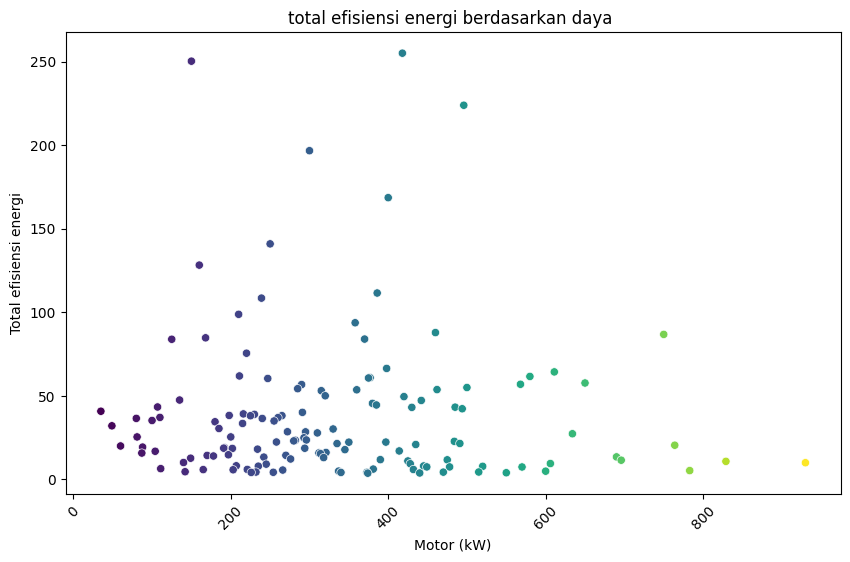

In [ ]:
Energy_Efficiency = df.groupby('Motor (kW)')['Energy Efficiency (km/kWh)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.scatterplot(x=Energy_Efficiency.index, y=Energy_Efficiency.values, palette='viridis', hue=Energy_Efficiency.index, legend=False)
plt.title('total efisiensi energi berdasarkan daya ')
plt.xlabel('Motor (kW)')
plt.ylabel('Total efisiensi energi')
plt.xticks(rotation=45)
plt.show()

Titik data menyebar secara acak tidak membentuk garis naik atau turun yang jelas, artinya tidak ada hubungan linier yang kuat antara daya kendaraan dengan tingkat efisiensi energi dan bisa dikatakan besarnya daya kendaraan bukan faktor utama yang mempengaruhi efisiensi dari kendaraan.

kesimpulannya kendaraan listrik dengan daya yang yang besar tidak selalu memiliki efisiensi energi yang tinggi.

#Composition

Aktivitas: Melihat proporsi atau persentase merek kendaraan berdasarkan tingkat efisiensi energinya.

Tujuan: Mengetahui kategori merek kendaraan mana yang paling mendominasi dalam aspek efisiensi energi.

Visualisasi: Pie Chart (Grafik Lingkaran).

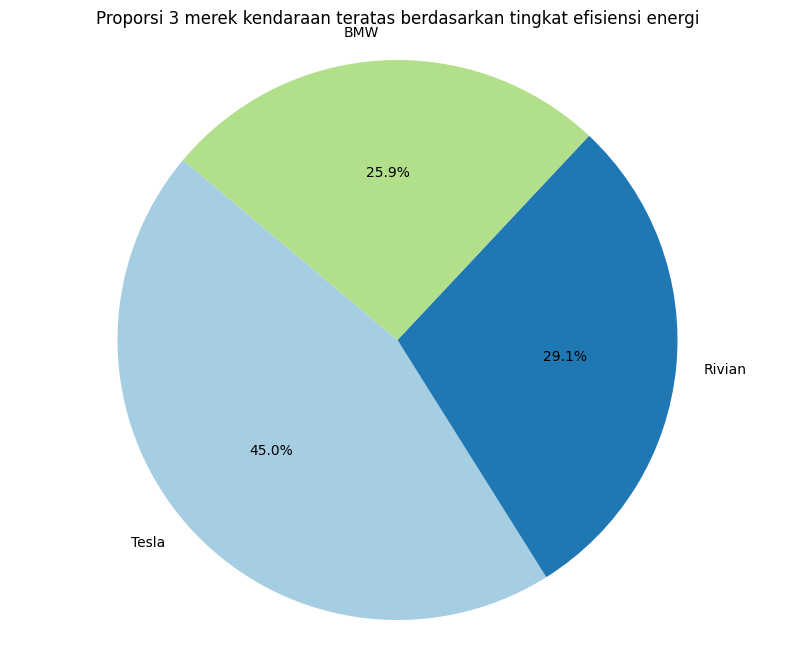

In [ ]:
Make_by_Energy_Efficiency = df.groupby('Make')['Energy Efficiency (km/kWh)'].sum().sort_values(ascending=False)
Make_by_Energy_Efficiency_top3 = Make_by_Energy_Efficiency.head(3)

plt.figure(figsize=(10, 8))
Make_by_Energy_Efficiency_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi 3 merek kendaraan teratas berdasarkan tingkat efisiensi energi')
plt.ylabel('')
plt.axis('equal')
plt.show()

Visualisasi composition menggunakan pie chart menunjukkan bahwa Tesla memiliki kontribusi efisiensi energi yang paling tinggi sebesar 45%, lalu disusul Rivian sebesar 29,1%, dan BMW sebesar 25,9%. Hal ini menunjukkan bahwa Tesla mendominasi dalam aspek efisiensi energi dibandingkan dua merek lainnya. selain itu Rivian dan BMW memiliki proporsi yang berdekatan, hal ini menunjukkan adanya tingkat efisiensi energy yang kompetitif diantara keduanya.

#Distribution

Aktivitas: Melakukan analisis distribusi nilai efisiensi energi kendaraan listrik dan bagaimana pola penyebaran datanya.

Tujuan: mengidentifikasi apakah mayoritas kendaraan memiliki efisiensi energi yang rendah, sedang, atau tinggi, serta melihat pola distribusi apakah nilai normal, miring, atau ekstrem.

Visualisasi: Histogram.

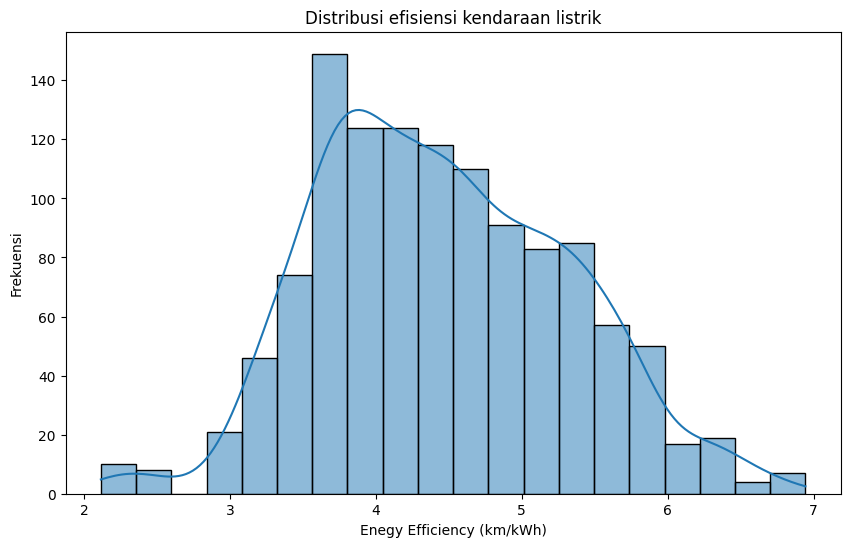

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Energy Efficiency (km/kWh)'], bins=20, kde=True)
plt.title('Distribusi efisiensi kendaraan listrik')
plt.xlabel('Enegy Efficiency (km/kWh)')
plt.ylabel('Frekuensi')
plt.show()

Berdasarkan grafik, mayoritas kendaraan memiliki efisiensi energi pada rentang 3,5 hingga 5,0 km/kWh. Distribusi data menunjukkan pola yang mendekati normal, hal ini berarti penyebaran performa efisiensi energi relatif seimbang antar kendaraan. selain itu ada beberapa kendaraan dengan efisiensi energi yang tinggi di atas 6 km/kWh, hal ini menunjukkan adanya variasi teknologi efisiensi energi pada beberapa model kendaraan.

#Relationship

Aktivitas: Melakukan analisis korelasi antar variabel numerik

Tujuan: Mengetahui bagaimana hubungan antara tahun model, daya kendaraan, waktu pengisian daya, dan efisiensi energi

Visualisasi: Heatmap

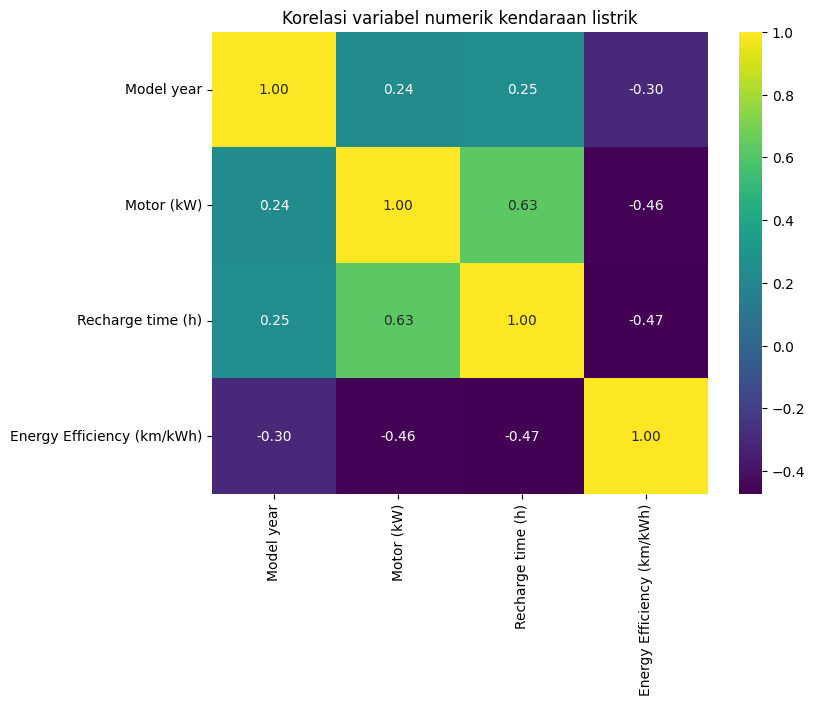

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Model year', 'Motor (kW)', 'Recharge time (h)', 'Energy Efficiency (km/kWh)']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi variabel numerik kendaraan listrik')
plt.show()

1. Motor (kW) vs Recharge time (h) nilainya 0.63 positif dan cukup kuat. Artinya semakin besar daya kendaraan, semakin lama waktu chargingnya. karena semakin besar daya suatu kendaraan semakin besar baterainya dan baterai yang besar waktu pengisiannya akan lebih lama.
2. Motor (kW) vs Energy Efficiency (km/kWh) nilainya -0.46 negatif dan sedang. Artinya semakin besar daya motor, efisiensi energi cenderung menurun. daya yang besar sama dengan tenaga yang besar tapi konsumsi energi yang boros.
3. Recharge time (h) vs Energy Efficiecy (km/kWh) nilainya -0.47 negatif dan sedang. Artinya semakin lama waktu charging, efisiensi energi cenderung rendah. karena mobil dengan baterai besar butuh charging yang lama, tapi biasanya konsumsi energinya juga besar.
4. Model year vs Motor (kW) nilainya 0.24 positif dan lemah. Artinya semakin baru tahun kendaraan, daya kendaraan cenderung menurun. karena kemungkinan kendaraan listrik terbaru itu hanya dirancang untuk performa yang tinggi.
5. Model year vs Recharge time (h) nilainya 0.25 positif dan lemah. Artinya mobil baru waktu chargingnya lebih lama karena bisa jadi mobil baru memiliki baterai yang besar dan baterai yang besar itu waktu pengisiannya lama.
6. model year vs Energy Efficiency (km/kWh) nilainya -0,30 negatif dan lemah. Artinya semakin terbaru mobil efisiensinya sedikit menurun, karena kemungkinan mobil baru berfokus pada performa

#Data Preparation

##1. Tipe Data

In [ ]:
df.dtypes

,0
Model year,int64
Make,object
Model,object
Vehicle class,object
Motor (kW),int64
Recharge time (h),float64
Energy Efficiency (km/kWh),float64


setelah dicek semua tipe data sudah sesuai dan ideal untuk analisis data artinya tipe data ini tidak perlu ada yang diubah.

##2. Inconsistent Value

* Make

In [ ]:
print(df['Make'].unique())

['Mitsubishi' 'Nissan' 'Ford' 'smart' 'Tesla' 'Chevrolet' 'BMW' 'Kia'
 'Tesla ' 'Hyundai' 'Volkswagen' 'Audi' 'Jaguar' 'smart EQ' 'MINI'
 'Porsche' 'Polestar' 'Volvo' 'Lucid' 'Mazda' 'Mercedes-Benz' 'Rivian'
 'Cadillac' 'Fisker' 'Genesis' 'Lexus' 'Subaru' 'Toyota' 'VinFast' 'Acura'
 'Dodge' 'FIAT' 'GMC' 'Honda' 'Jeep' 'Rolls-Royce' 'Ford ']


mengecek inconsistent values

In [ ]:
df['Make'] = df['Make'].replace({
    'Ford ': 'Ford',
    'Tesla ': 'Tesla'

})

for col in ['Make']:
    print(df[col].unique())

['Mitsubishi' 'Nissan' 'Ford' 'smart' 'Tesla' 'Chevrolet' 'BMW' 'Kia'
 'Hyundai' 'Volkswagen' 'Audi' 'Jaguar' 'smart EQ' 'MINI' 'Porsche'
 'Polestar' 'Volvo' 'Lucid' 'Mazda' 'Mercedes-Benz' 'Rivian' 'Cadillac'
 'Fisker' 'Genesis' 'Lexus' 'Subaru' 'Toyota' 'VinFast' 'Acura' 'Dodge'
 'FIAT' 'GMC' 'Honda' 'Jeep' 'Rolls-Royce']


Alasan menggunakan metode ini karena kata ford dan tesla itu ada yang menggunakan spasi dan ada yang tidak sehingga sistem mendetek itu kata yang berbeda, maka kata tersebut harus disamakan dengan kata yang lain yaitu tanpa menggunakan spasi. artinya metode ini sangat cocok untuk penanganan ini.

##3. Missing Values

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Model year,0.0
Make,0.0
Model,0.0
Vehicle class,0.0
Motor (kW),0.0
Recharge time (h),0.0
Energy Efficiency (km/kWh),0.0


Berdasarkan hasil pengecekkan data, null ratio tiap kolomnya 0% artinya tidak ada missing value pada dataset ini semua baris memiliki data yang lengkap

##4. Duplicated

In [ ]:
df[df.duplicated()]

,Model year,Make,Model,Vehicle class,Motor (kW),Recharge time (h),Energy Efficiency (km/kWh)


Berdasarkan hasil pengecekkan data, di dataset ini terlihat tidak ada duplikasi, artinya setiap data pada dataset bersifat unik dan tidak perlu ditangani untuk penghapusan duplikat.

##5. Outlier

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Model year,7.017544
Motor (kW),2.422723
Recharge time (h),1.336675
Energy Efficiency (km/kWh),0.000000


Outlier sebelum ditangani

In [ ]:
columns_to_impute = ["Motor (kW)", "Recharge time (h)"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

Alasan menggunaka metode IQR ini karena persentase outlier relatif kecil sehingga nilai ekstrem hanya ada sedikit. Dalam kondisi ini metode IQR sangat efektif dalam mendeteksi dan membatasi nilai yang menyimpang tanpa harus menghapus data.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Model year,7.017544
Motor (kW),0.000000
Recharge time (h),0.000000
Energy Efficiency (km/kWh),0.000000


outlier setelah ditangani menjadi 0% atau tidak ada outlier kecuali kolom model year yang memang dari awal tidak ditangani. meskipun model year memiliki outlier sebesar 7% nilai tersebut mempresentasikan variasi tahun produksi kendaraan bukan kesalahan data. oleh karena itu kolom model year tidak dilakukan penyesuaian ataupun penghapusan.

#Data Contraction

In [ ]:
def Efficiency_level(jarak):
    if jarak > 5:
        return 'sangat efisien'
    elif jarak < 4:
        return 'kurang efisien '
    else:
        return 'cukup efisien'

df['Efficiency_level'] = df['Energy Efficiency (km/kWh)'].apply(Efficiency_level)

In [ ]:
df.head()

,Model year,Make,Model,Vehicle class,Motor (kW),Recharge time (h),Energy Efficiency (km/kWh),Efficiency_level
0,2012,Mitsubishi,i-MiEV,Subcompact,49,7.0,5.347594,sangat efisien
1,2012,Nissan,LEAF,Mid-size,80,7.0,4.739336,cukup efisien
2,2013,Ford,Focus Electric,Compact,107,4.0,5.000000,cukup efisien
3,2013,Mitsubishi,i-MiEV,Subcompact,49,7.0,5.347594,sangat efisien
4,2013,Nissan,LEAF,Mid-size,80,7.0,4.739336,cukup efisien


Kolom baru yang dibuat adalah Efficiency_level, kolom ini dibuat berdasarkan Energy_Efficiency (km/kWh) dengan cara mengelompokkannya menjadi tiga bagian yaitu kurang efisien, cukup efisien, dan sangat efisien. Tujuannya supaya data Energy_Efficincy (km/kWh) memiliki versi data kategorikalnya agar lebih mudah dipahami dan mempermudah dalam menganalisis tingkat efisiensi energi kendaraan listrik. Manfaatnya meningkatkan kualitas informasi dataset dan membantu dalam pengambilan keputusan terkait efisien energy kendaraan listrik.

#Data Reduction

In [ ]:
df = df.drop('Model', axis=1)

In [ ]:
df.head()

,Model year,Make,Vehicle class,Motor (kW),Recharge time (h),Energy Efficiency (km/kWh),Efficiency_level
0,2012,Mitsubishi,Subcompact,49,7.0,5.347594,sangat efisien
1,2012,Nissan,Mid-size,80,7.0,4.739336,cukup efisien
2,2013,Ford,Compact,107,4.0,5.000000,cukup efisien
3,2013,Mitsubishi,Subcompact,49,7.0,5.347594,sangat efisien
4,2013,Nissan,Mid-size,80,7.0,4.739336,cukup efisien


Alasan menghapus kolom Model karena kolom ini memiliki banyak kategori unik dan tidak memberikan dampak atau pengaruh yang besar terhadap analisis efisiensi energi kendaraan listrik, sehingga dihapusnya kolom model ini dapat menyederhanakan dataset tanpa menghilangkan informasi atau data yang penting mengenai analisis ini.

In [ ]:
df.to_csv('Energy_Efficiency_bersih.csv', index=False)

#Visualisasi Data

##Bar Chart

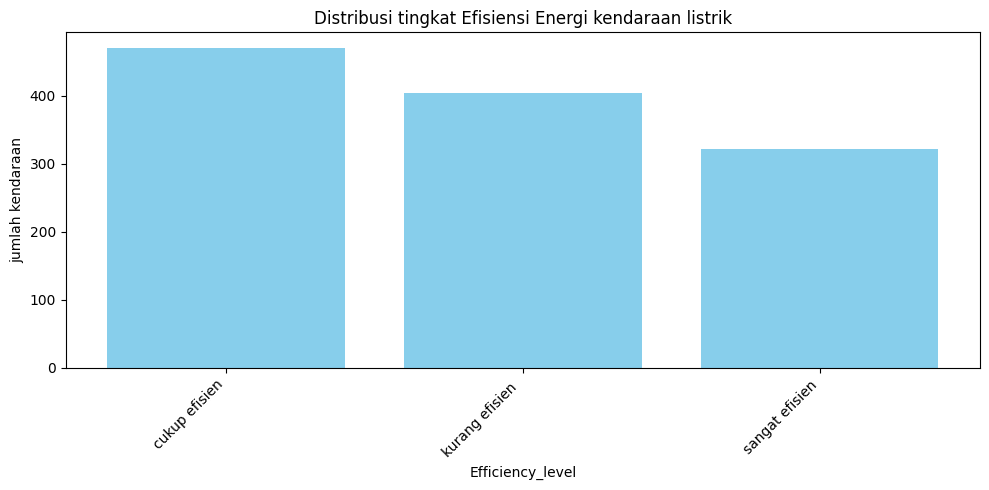

In [ ]:
level_efesiensi = df['Efficiency_level'].value_counts().head(5).sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan

plt.figure(figsize=(10, 5)) # Ukuran
plt.bar(level_efesiensi.index, level_efesiensi.values, color='skyblue') # color warna
plt.xlabel('Efficiency_level') # keterangan X label
plt.ylabel('jumlah kendaraan') # keterangan y label
plt.title('Distribusi tingkat Efisiensi Energi kendaraan listrik') # Judul
plt.xticks(rotation=45, ha='right') # rotasi teks
plt.tight_layout()
plt.show()

Insight
* Kategori tingkat efisiensi energi dengan keterangan "cukup efisien" paling banyak dimiliki oleh kendaraan dalam dataset ini.
* Kategori tingkat efisiensi energi dengan keterangan "kurang efisien" cukup banyak dimiliki oleh kendaraan dalam dataset ini. Artinya masih cukup banyak kendaraan yang efisiensi energinya masing kurang optimal.
* Kategori tingkat efisiensi energi dengan keterangan "sangat efisien" sangat dimiliki oleh kendaraan dalam dataset ini. Artinya hanya sedikit kendaraan yang efisiensi energinya yang baik.

Action
* Mengembangkan teknologi efisiensi energi kendaraan listrik dengan memfokuskan peningkatan teknologi baterai dan motor kendaraan listrik agar meningkatkan efisiensi energinya.

##Pie Chart

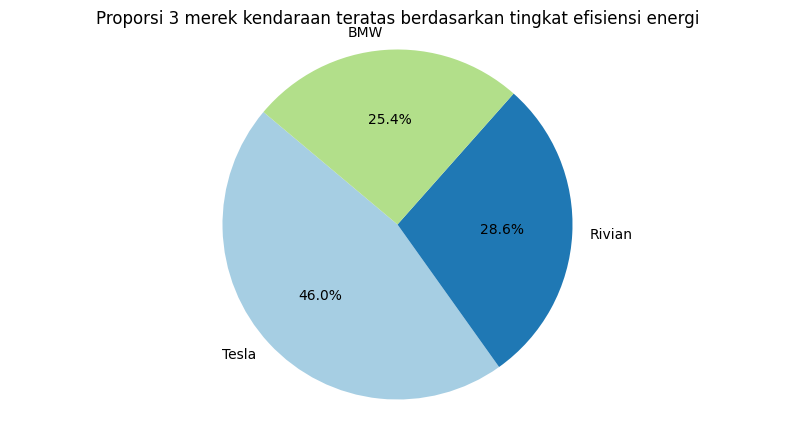

In [ ]:
Make_by_Energy_Efficiency = df.groupby('Make')['Energy Efficiency (km/kWh)'].sum().sort_values(ascending=False)
Make_by_Energy_Efficiency_top3 = Make_by_Energy_Efficiency.head(3)

plt.figure(figsize=(10, 5))
Make_by_Energy_Efficiency_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi 3 merek kendaraan teratas berdasarkan tingkat efisiensi energi')
plt.ylabel('')
plt.axis('equal')
plt.show()

Insight
* Tesla memiliki proporsi efisensi energi sebesar 46.0%. Artinya jumlah kendaraan terbanyak yang memiliki efisiensi energi yang tinggi dimiliki oleh kendaraan dengan merek tesla.
* Rivian memiliki proporsi efisensi energi sebesar 28.6%. Artinya merek kendaraan Rivian cukup dominan dalam memiliki efisiensi energi tetapi masih cukup jauh dibawah tesla
* BMW memiliki proporsi efisiensi energi sebesar 25.4%. Artinya disini BMW dan Rivian memiliki proporsi yang berdekatan, hal ini menunjukkan adanya tingkat efisiensi energy yang kompetitif diantara keduanya.

Action
* Produsen bisa dapat mempelajari teknologi efisiensi energi kendaraan tesla untuk meingkatkan efisien energi kendaraan listrik mereka.
* Rivian dan BMW dapat meningkatkan inovasi teknologi baterai dan motor mereka agar bisa bersaing dengan tesla dalam efisiensi energi.

##Line Chart

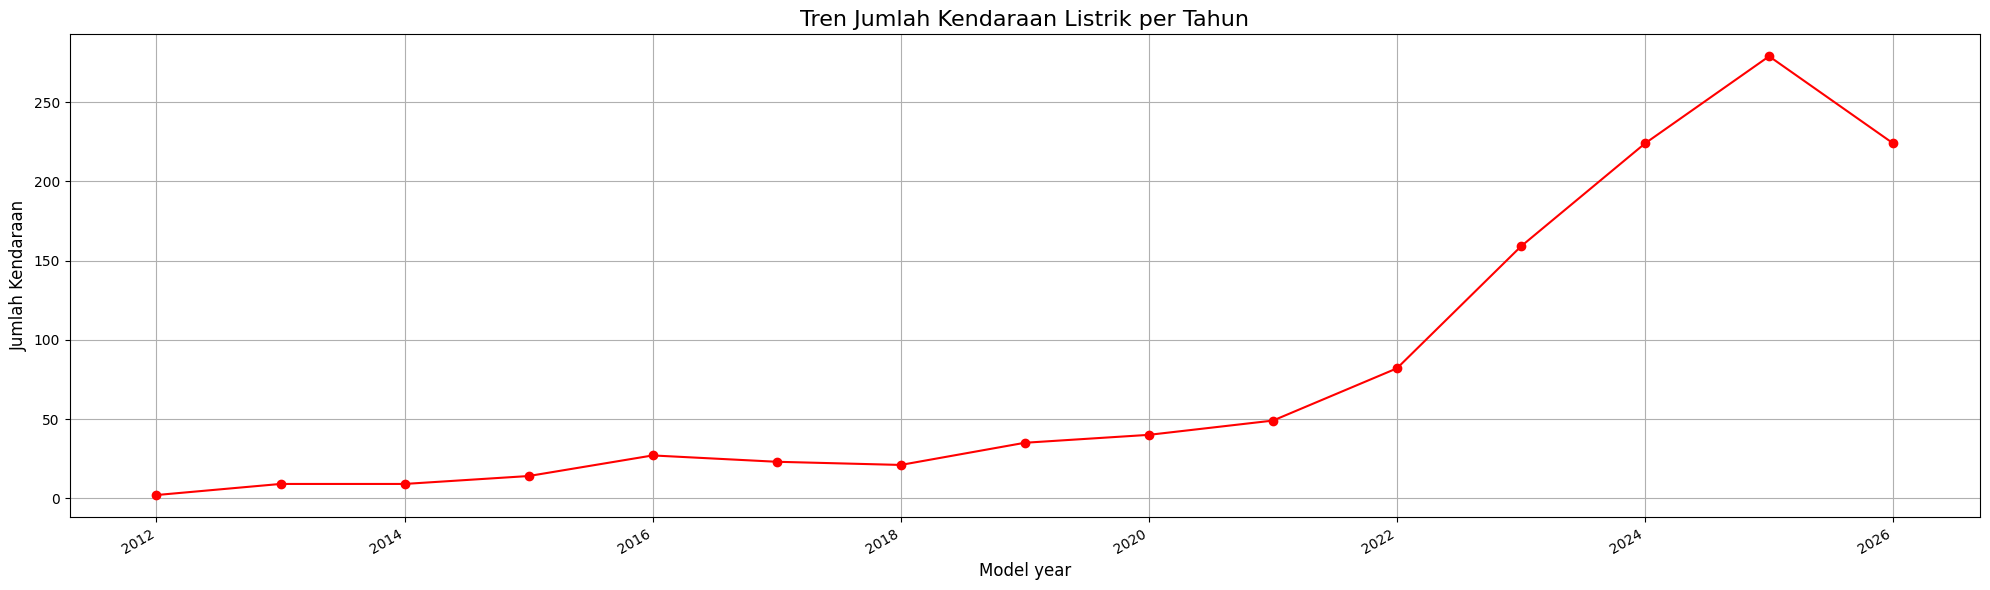

In [ ]:
# Group by year
TrenJumlahKendaraan = df.groupby(df['Model year']).size()

plt.figure(figsize=(20, 6)) # Ukuran
plt.plot(TrenJumlahKendaraan.index, TrenJumlahKendaraan.values, marker='o', color='red') # Color = Warna
plt.title('Tren Jumlah Kendaraan Listrik per Tahun', fontsize=16) # Judul
plt.xlabel('Model year', fontsize=12) # X Keterangan
plt.ylabel('Jumlah Kendaraan', fontsize=12) # Y Keterangan'
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

Insight
* Terjadi peningkatan jumlah kendaraan listrik dari tahun ke tahun, mulai tahu 2012-2021 peningkatannya masih lambat dan stabil.
* Setelah tahun 2022 jumlah kendaraan listrik terjadi lonjakan yang sangat tajam, yang menandakan perkembangan teknologi dan pasar EV yang semakin pesat.
* Tahun 2025 merupakan puncak tertinggi dari jumlah kendaraan dalam dataset ini.
* Terjadi sedikit penurunan di tahun 2026 karena mungkin masih di awal tahun dan masih sedikit jumlah produksi kendaraannya.

Action
* Memanfaatkan tren peningkatan permintaan kendaraan listrik setelah tahun 2022 dengan meningkatkan produksi, teknologi, dan inovasi agar bisa bersaing dengan merek kendaraan lain.
* Mendukung infrastruktur seperti statiun pengisian daya listrik kendaraan.

##Histogram

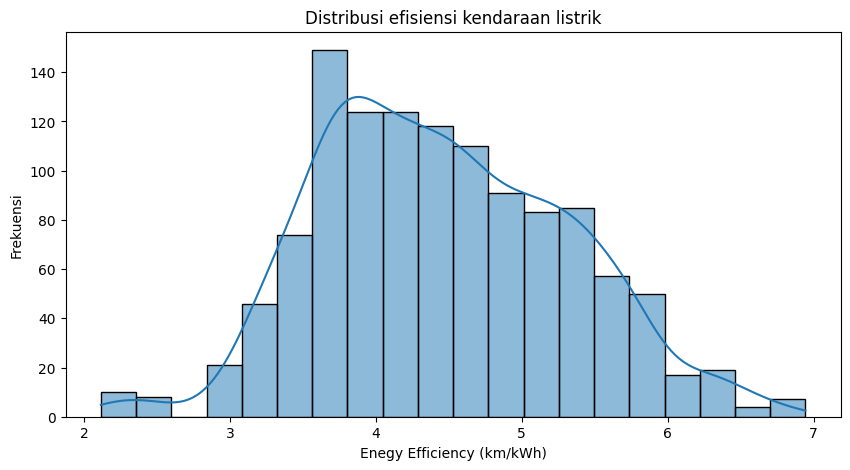

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Energy Efficiency (km/kWh)'], bins=20, kde=True)
plt.title('Distribusi efisiensi kendaraan listrik')
plt.xlabel('Enegy Efficiency (km/kWh)')
plt.ylabel('Frekuensi')
plt.show()

Insight
* Sebagian besar efisiensi energi yang besar berada di rentang 4-5 (km/kWh) yang artinya sebagian besar efisiensi energi kendaraan listrik dalam dataset ini memiliki rentang tersebut.
* Distribusi ini berbentuk lonceng yang artinya distribusi efisiensi energi kendaraan listrik dalam dataset ini normal dan variasi efisiensi nya yang wajar.
* Nilai sangat rendah (<3 km/kWh) dan sangat tinggi (>6 km/kWh) jumlahnya sedikit. Artinya kendaraan yang efisiensinya buruk dan sangat bagus itu jumlahnya tidak banyak.

Action
* Kendaraan dengan efisiensi energi 3 (km/kWh) perlu dilakukan evaluasi dan peningkatan teknologi baterai dan motor kendaraan untuk meningkatkan efisiensi energi.
* Karena kebanyakan kendaraan memiliki efisiensi energi dalam rentang 4-5 (km/kWh) maka produsen perlu terus mengembagkan teknologi agar efisiensi energi bisa meningkat.
* Mempelajari kendaraan dengan efisiensi energi >6 (km/kWh) bagaimana kendaraan tersebut bisa memiliki efisiensi kendaraan listrik yang tinggi.


##BoxPlot

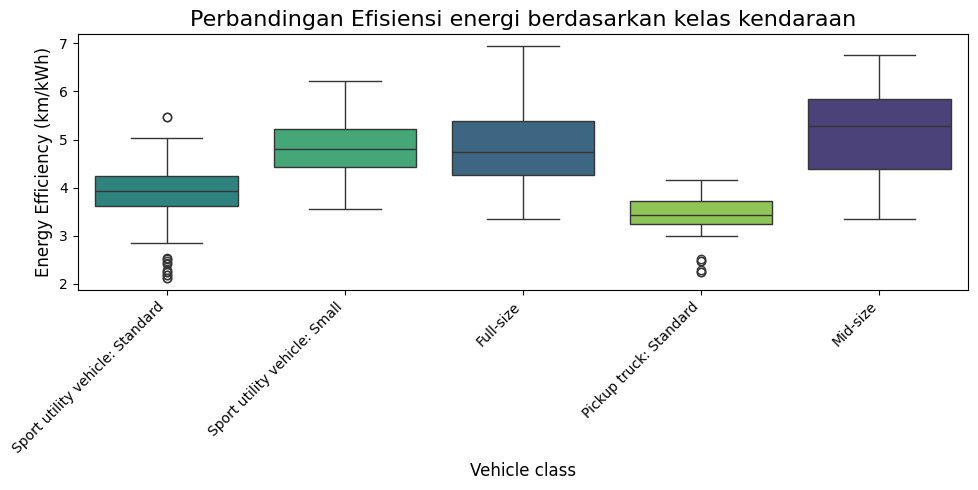

In [ ]:
KelasKendaraan = df['Vehicle class'].value_counts().head(5).index
EfisiensiEnergi = df[df['Vehicle class'].isin(KelasKendaraan)]

plt.figure(figsize=(10, 5)) # Ukuran figure
sns.boxplot(x='Vehicle class', y='Energy Efficiency (km/kWh)', data=EfisiensiEnergi, palette='viridis', order=KelasKendaraan, hue='Vehicle class', legend=False)
plt.title('Perbandingan Efisiensi energi berdasarkan kelas kendaraan', fontsize=16) # Judul
plt.xlabel('Vehicle class', fontsize=12) # X Keterangan
plt.ylabel('Energy Efficiency (km/kWh)', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Insight
* Pickup truck: Standard memiliki efisiensi yang paling rentang median efisiensinya hanya sekitar 3-3.3 km/kWh, efisiensi nya yang paling rendah dibandingkan dengan kelas kendaraan lainnya.
* Sport utility vehicle: small dan Mid-size memiliki efisiensi relatif tinggi dengan rentang median efisiensi sebesar 4.5-5 km/kWh.
* Full-size memiliki rentang BoxPlot yang cukup lebar, artinya efisiensi kendaraan kelas Full-size cukup bervariasi.
* Terdapat nilat outlier pada kelas kendaraan Sport utility vehicle: standard dan Pickup truck: Standard karena terdapat nilai efisien yang sangat rendah dari nilai rata-rata.

Action
* Mengembangkan teknologi pada kelas kendaraan Pickup truck: standard dan Sport utility vehicle: Standard untuk meningkatkan efisiensinya karena kelas kendaraan ini memiliki efisiensi paling rendah.
* Menjadikan kelas kendaraan Sport utility vehicle: small dan mid-size sebagai standar pengembangan karena kelas kendaraan ini memilik efisiensi yang lebih baik.
* Mencari penyebab kelas kendaraan yang memiliki efisiensi yang rendah.

##ScatterPlot

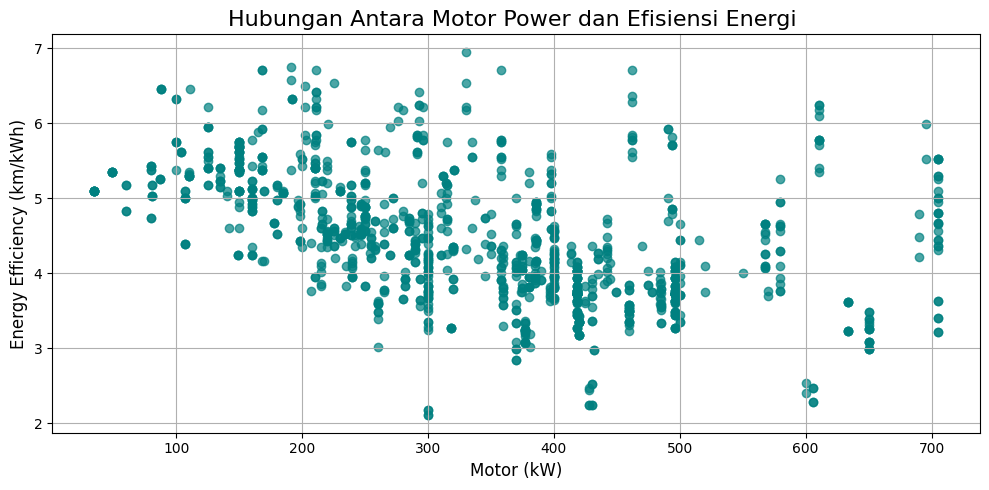

In [ ]:
plt.figure(figsize=(10, 5)) # Ukuran
plt.scatter(df['Motor (kW)'], df['Energy Efficiency (km/kWh)'], alpha=0.7, color='teal') # Color (Warna)
plt.title('Hubungan Antara Motor Power dan Efisiensi Energi ', fontsize=16) # Judul
plt.xlabel('Motor (kW)', fontsize=12) # X Keterangan
plt.ylabel('Energy Efficiency (km/kWh)', fontsize=12) # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

Insight
* Terdapat kecendrungan hubungan negatif antara Motor power dan efisiensi energi, yang artinya semakin besar motor power maka efisiensi energi cenderung menurun.
* Kendaraan dengan motor power kecil hingga menengah (sekitar 100-300 kW) memiliki efisiensi energi yang cukup tinggi. titik data ini banyak berada di efisiensi sekitar 5-6 km/kWh.
* Kendaraan dengan motor power besar (sekitar 400 kW) memiliki efisiensi energi yang rendah dan bervariasi. titik data ini banyak berada di efisiensi sekitar 3-4.5 km/kWh.

Action
* Memfokuskan pada pengembangan kendaraan dengan power motor menengah (200-300 kW) karena dapat memberikan keseimbangan antara performa dan efisiensi enrgi.
* Mencari solusi pada kendaraan yang memiliki power motor yang besar (>400 kW) agar bisa memiliki efisiensi energi yang besar.

##Heatmap

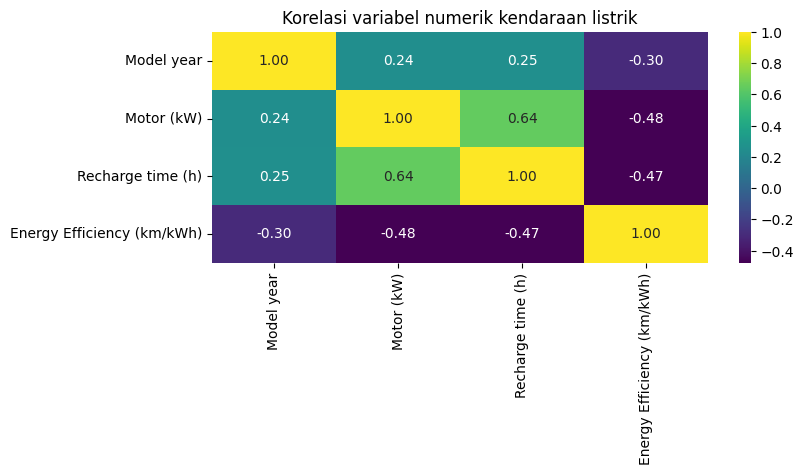

In [ ]:
plt.figure(figsize=(8, 3))
sns.heatmap(data=df[['Model year', 'Motor (kW)', 'Recharge time (h)', 'Energy Efficiency (km/kWh)']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi variabel numerik kendaraan listrik')
plt.show()

Insight
* Motor (kW) vs Recharge time (h) nilainya 0.63 positif dan cukup kuat. Artinya semakin besar daya kendaraan, semakin lama waktu chargingnya. karena semakin besar daya suatu kendaraan semakin besar baterainya dan baterai yang besar waktu pengisiannya akan lebih lama.
* Motor (kW) vs Energy Efficiency (km/kWh) nilainya -0.46 negatif dan sedang. Artinya semakin besar daya motor, efisiensi energi cenderung menurun. daya yang besar sama dengan tenaga yang besar tapi konsumsi energi yang boros.
* Recharge time (h) vs Energy Efficiecy (km/kWh) nilainya -0.47 negatif dan sedang. Artinya semakin lama waktu charging, efisiensi energi cenderung rendah. karena mobil dengan baterai besar butuh charging yang lama, tapi biasanya konsumsi energinya juga besar.
* Model year vs Motor (kW) nilainya 0.24 positif dan lemah. Artinya semakin baru tahun kendaraan, daya kendaraan cenderung menurun. karena kemungkinan kendaraan listrik terbaru itu hanya dirancang untuk performa yang tinggi.
* Model year vs Recharge time (h) nilainya 0.25 positif dan lemah. Artinya mobil baru waktu chargingnya lebih lama karena bisa jadi mobil baru memiliki baterai yang besar dan baterai yang besar itu waktu pengisiannya lama.
* model year vs Energy Efficiency (km/kWh) nilainya -0,30 negatif dan lemah. Artinya semakin terbaru mobil efisiensinya sedikit menurun, karena kemungkinan mobil baru berfokus pada performa.

Action
* Mengoptimalkan kendaraan dengan motor power besar dengan meningkatkan teknologi efisiensi energi agar dapat meningkatkan efisiensi energi.
* Mengembangkan teknologi Fast charging dan baterai yane lebih efisien untuk meningkatkan performa kendaraan
* Memfokuskan pada pengembangan kendaraan dengan motor power menengah agar terciptanya keseimbangan antara performa, efisiensi energi dan waktu pengisian.